# Script to interact with CFR Insights API web site and plot KPIs

In [1]:
%matplotlib widget
import json
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
retry_strategy = Retry(
    total=10,
    backoff_factor=1
)
adapter = HTTPAdapter(max_retries=retry_strategy)

# Initialize the database

In [3]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    json_data = json.dumps({"force": True})
    response = session.post("http://127.0.0.1:8000/init-db", data=json_data)
    print(response.status_code)

201


# Populate the agency list with CFR references from the source (eCFR)

In [4]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    response = session.post("http://127.0.0.1:8000/agencies")
    print(response.status_code)

201


# Get the agency list with CFR references created in the above step

In [5]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    response = session.get("http://127.0.0.1:8000/agencies")
    print(response.status_code)
    data = response.json()
    print(json.dumps(data, indent=4))

200
[
    {
        "id": 1,
        "short_name": "ACUS",
        "name": "Administrative Conference of the United States",
        "parent_id": null,
        "cfr_references": [
            {
                "id": 1,
                "agency_id": 1,
                "parent_agency_id": null,
                "reference": {
                    "title": 1,
                    "chapter": "III"
                }
            }
        ]
    },
    {
        "id": 2,
        "short_name": "ACHP",
        "name": "Advisory Council on Historic Preservation",
        "parent_id": null,
        "cfr_references": [
            {
                "id": 2,
                "agency_id": 2,
                "parent_agency_id": null,
                "reference": {
                    "title": 36,
                    "chapter": "VIII"
                }
            }
        ]
    },
    {
        "id": 3,
        "short_name": "SIGAR",
        "name": "Special Inspector General for Afghanistan Reconstructi

# Generate CFR insights for USDA (agency_id=6) for different dates - this step will take a few minutes to complete

In [6]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    dates = ["2025-06-03", "2024-06-03", "2023-06-03", "2022-06-03", "2021-06-03", "2020-06-03"]
    for date in dates:
        json_data = json.dumps({"agency_id": 6, "date": date})
        response = session.post("http://127.0.0.1:8000/insights", data=json_data)
        print(response.status_code, response.text)

201 null

201 null

201 null

201 null

201 null

201 null



# Get details for regulatory sections which are directly referenced by USDA

In [11]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    reference_ids = [8, 9, 10, 11, 12]
    for r_id in reference_ids:
        response = session.get(f"http://127.0.0.1:8000/insights/{r_id}")
        print(response.status_code)
        data = response.json()
        print(json.dumps(data, indent=4))

200
[
    {
        "cfr_reference_id": 8,
        "agency_id": 6,
        "parent_agency_id": null,
        "date": "2025-06-03",
        "checksum": "eedf0b12dedbd543f875ceed899a3a589336d102c6e392f4f462f285b784e6d6",
        "word_count": 255746,
        "restrictive_terms_count": 2244
    },
    {
        "cfr_reference_id": 8,
        "agency_id": 6,
        "parent_agency_id": null,
        "date": "2024-06-03",
        "checksum": "c98d6c19534d33a190b2b72594c342f2c5f22251879e406862dcb300ad7b94da",
        "word_count": 14802,
        "restrictive_terms_count": 116
    },
    {
        "cfr_reference_id": 8,
        "agency_id": 6,
        "parent_agency_id": null,
        "date": "2023-06-03",
        "checksum": "c98d6c19534d33a190b2b72594c342f2c5f22251879e406862dcb300ad7b94da",
        "word_count": 14802,
        "restrictive_terms_count": 116
    },
    {
        "cfr_reference_id": 8,
        "agency_id": 6,
        "parent_agency_id": null,
        "date": "2022-06-03",
   

# Get the generated insights for USDA

In [12]:
with requests.session() as session:
    session.mount("http://", adapter)
    session.headers.update({"Content-Type": "application/json", "Accept": "application/json"})
    response = session.get("http://127.0.0.1:8000/insights/agency/6")
    data = response.json()

# Each Reference id represents one unique CFR reference for an agency; group insights by reference id. 

In [13]:
insights_by_reference_id = dict()
for insight in data:
    if insight["cfr_reference_id"] not in insights_by_reference_id:
        insights_by_reference_id[insight["cfr_reference_id"]] = list()
    insights_by_reference_id[insight["cfr_reference_id"]].append(insight)

# Plot how "Word Count" and "Restrictive Terms Count" have changed over time for each CFR reference in USDA
# Increasing "Word Count" and increasing "Restrictive Terms Count" could indicate more and stricter regulations over time

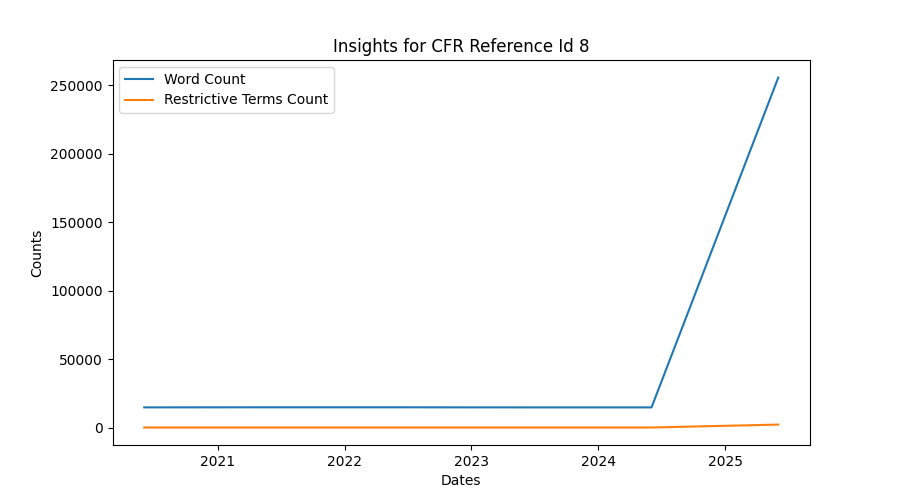

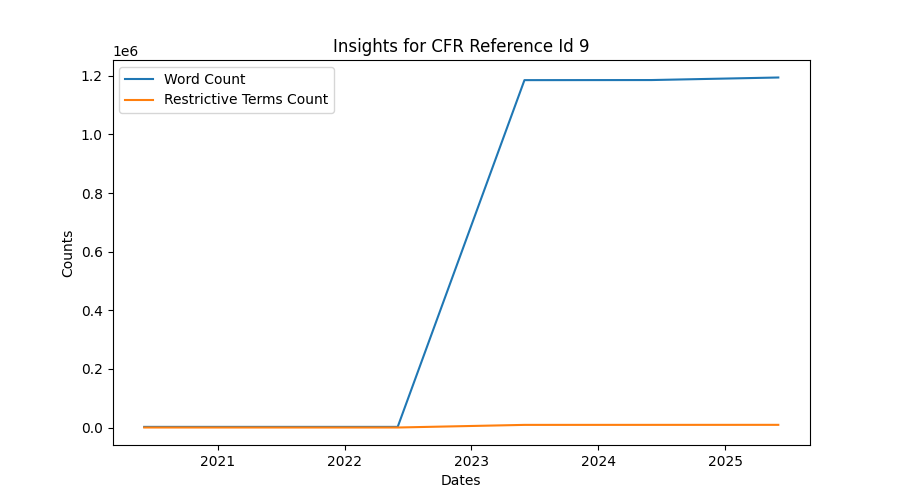

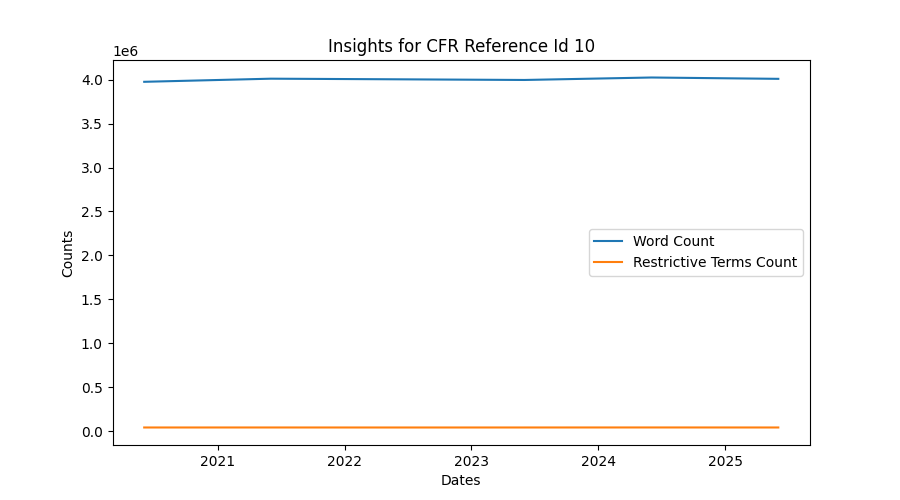

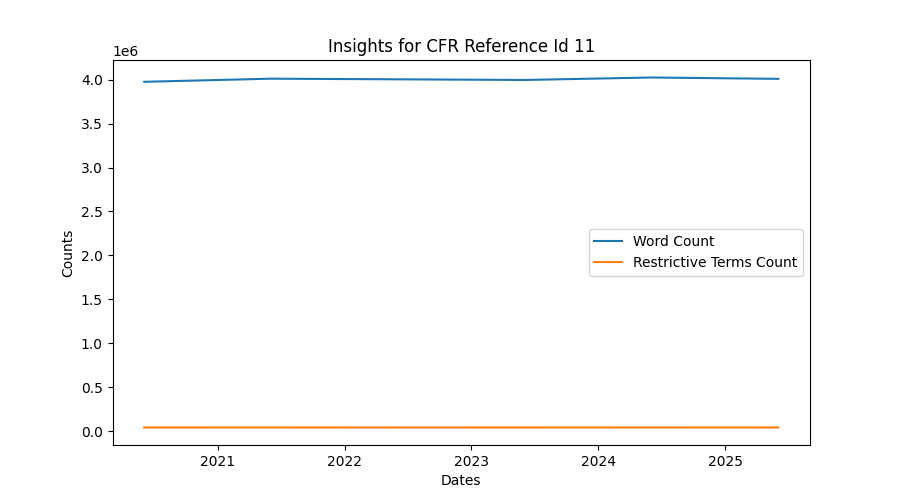

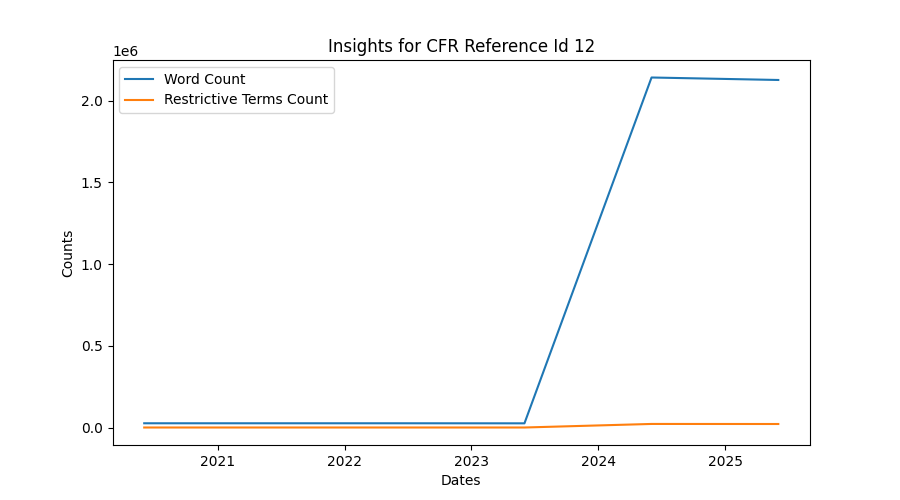

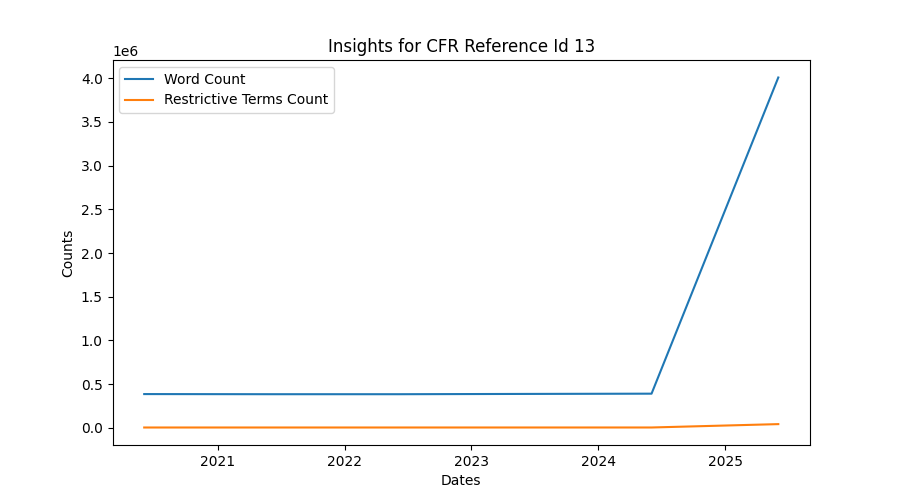

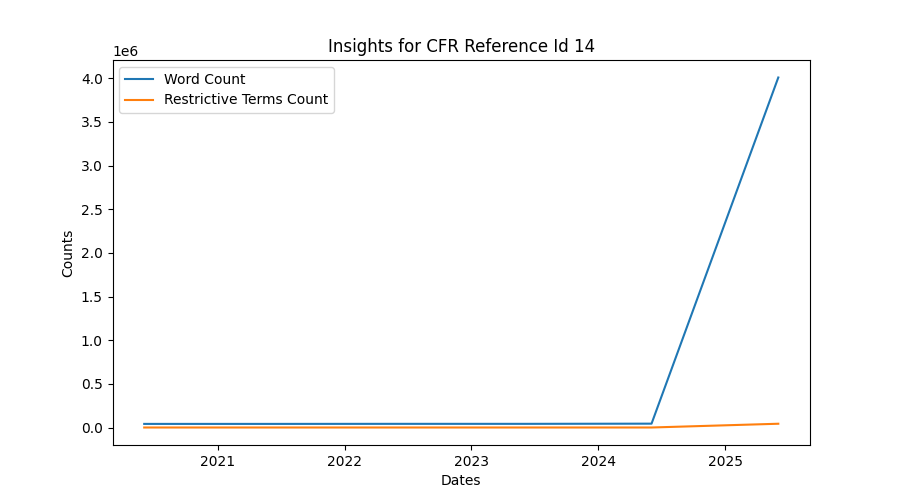

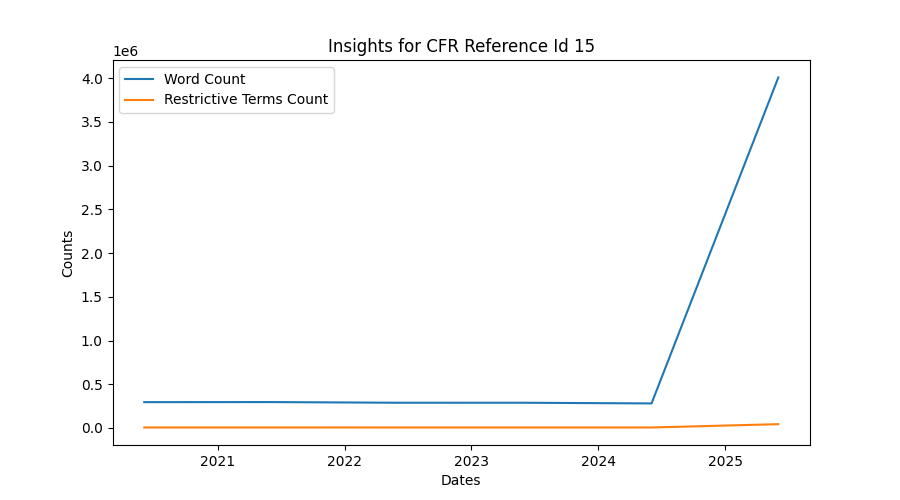

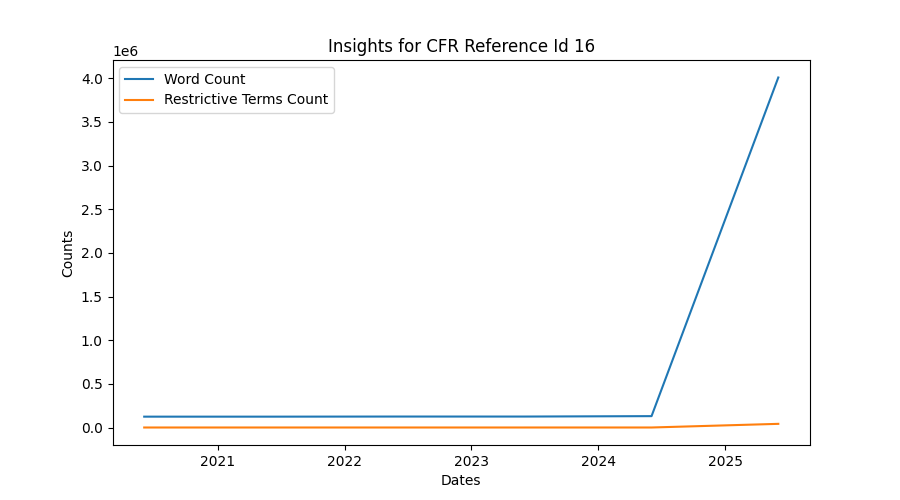

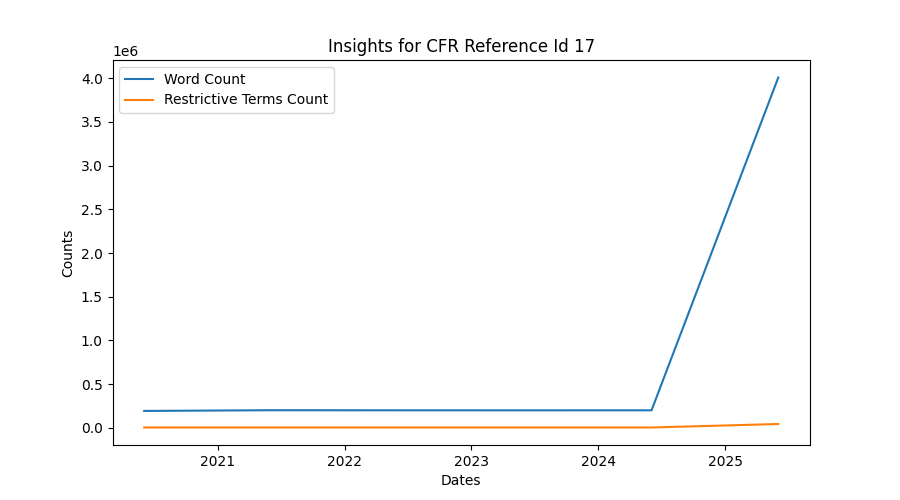

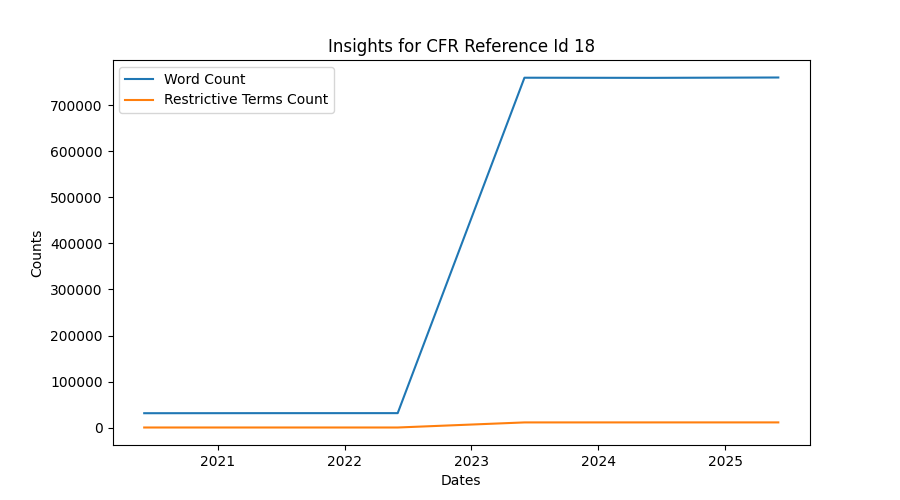

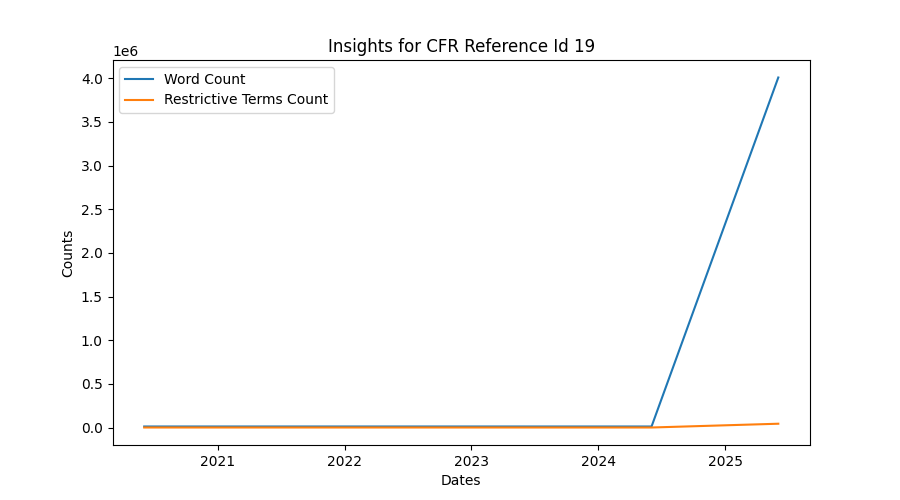

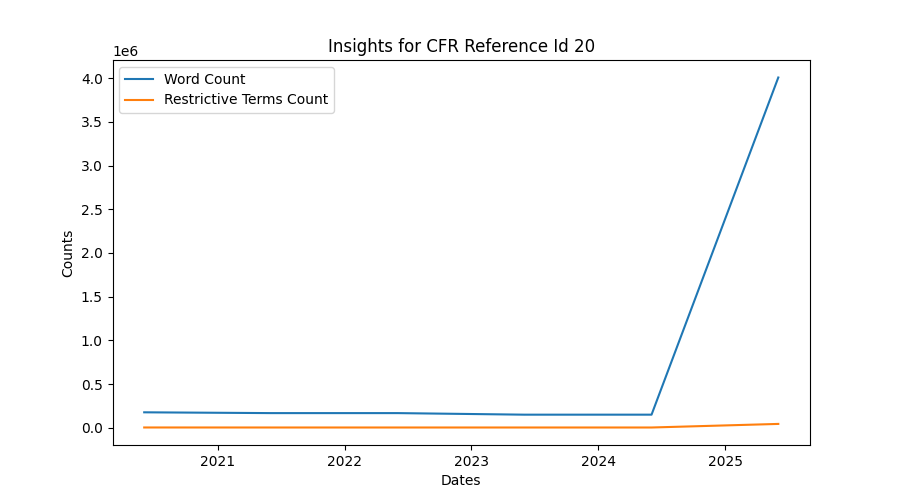

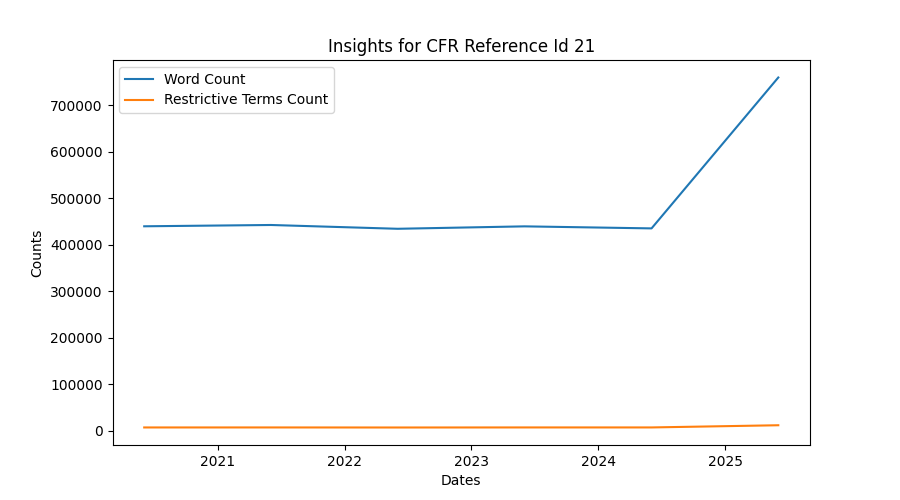

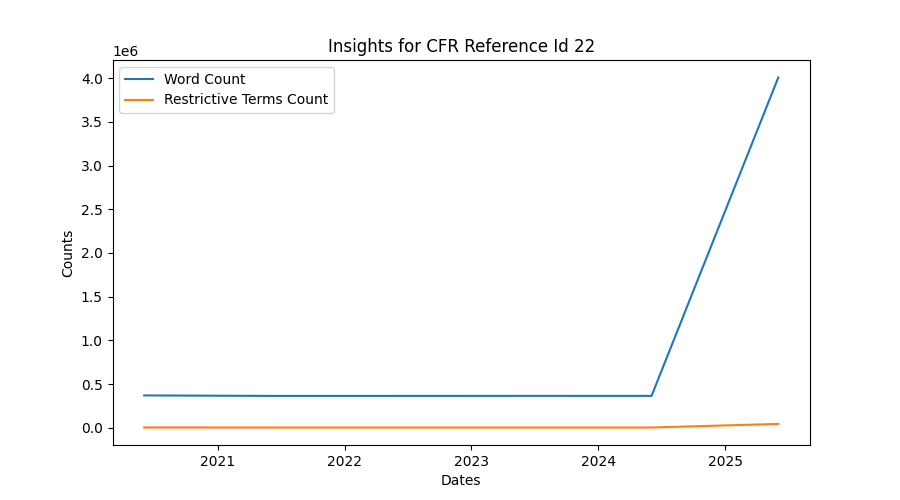

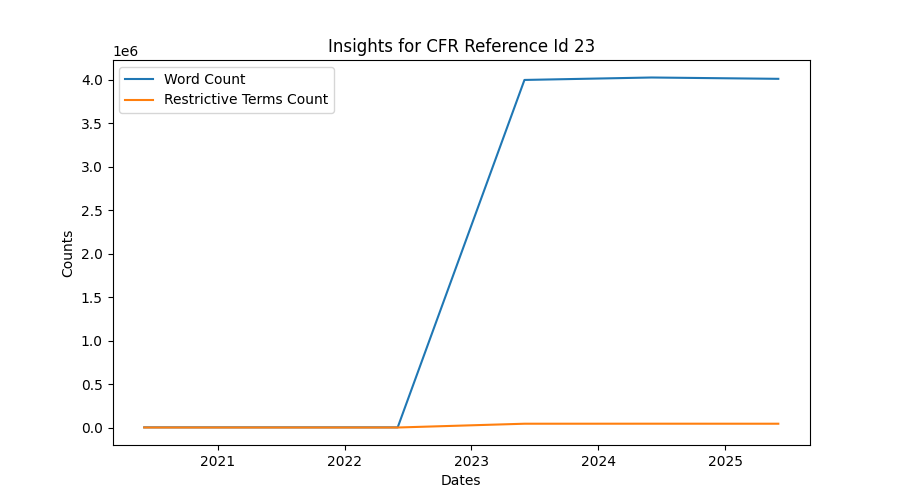

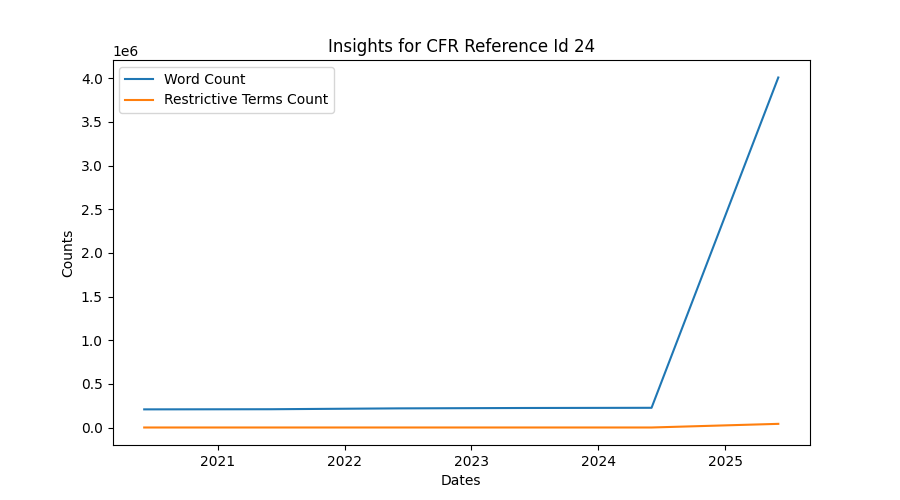

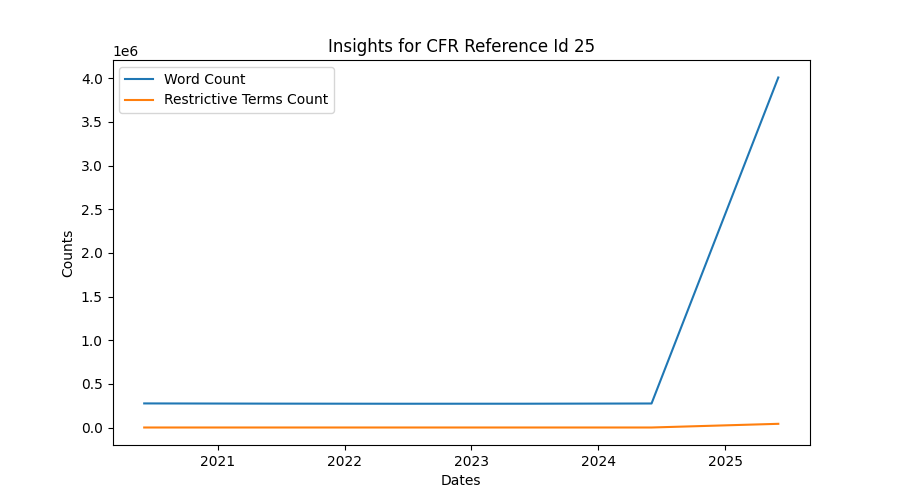

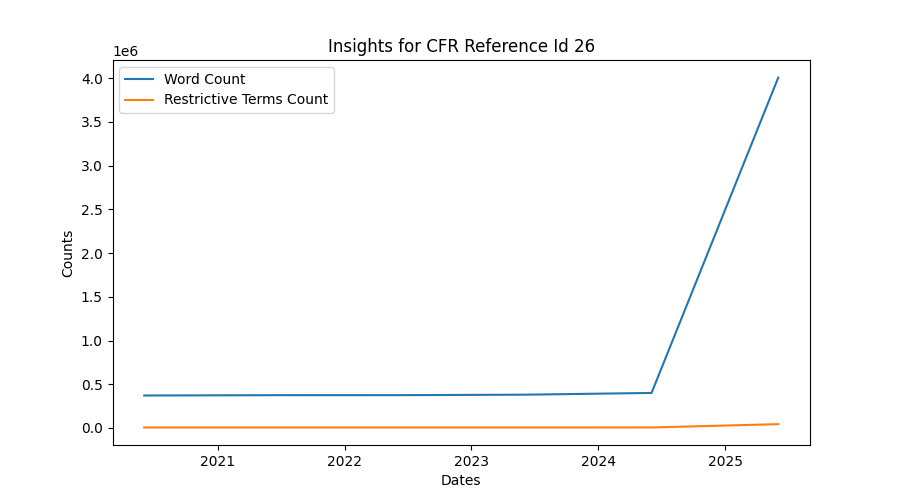

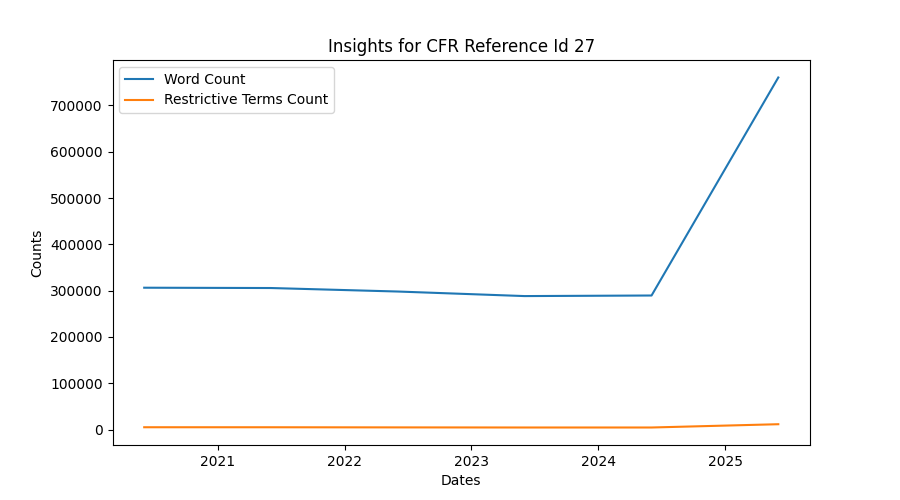

/var/folders/b6/mty8z4pn21vcb02l2tmrc22m0000gn/T/ipykernel_77803/3752845909.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(9, 5))


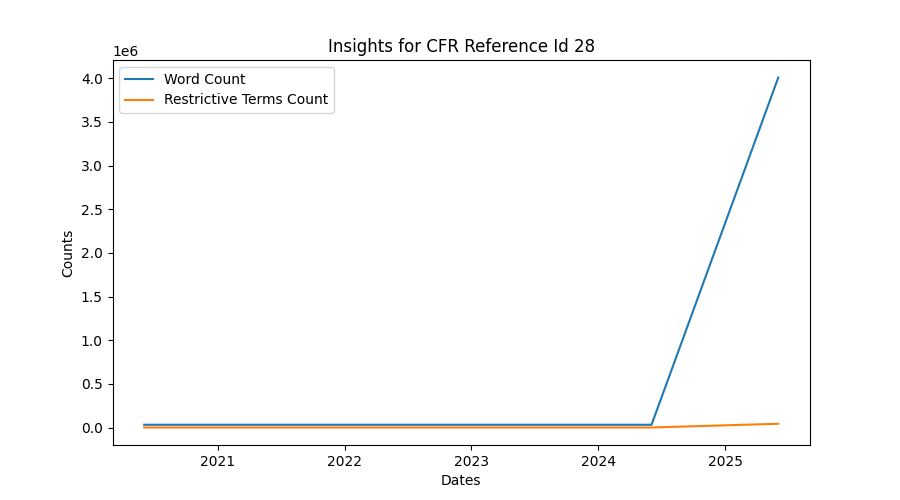

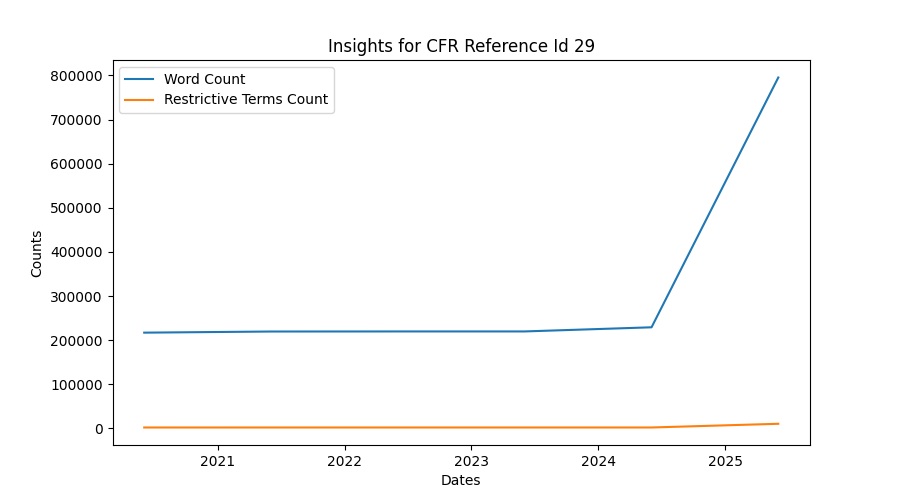

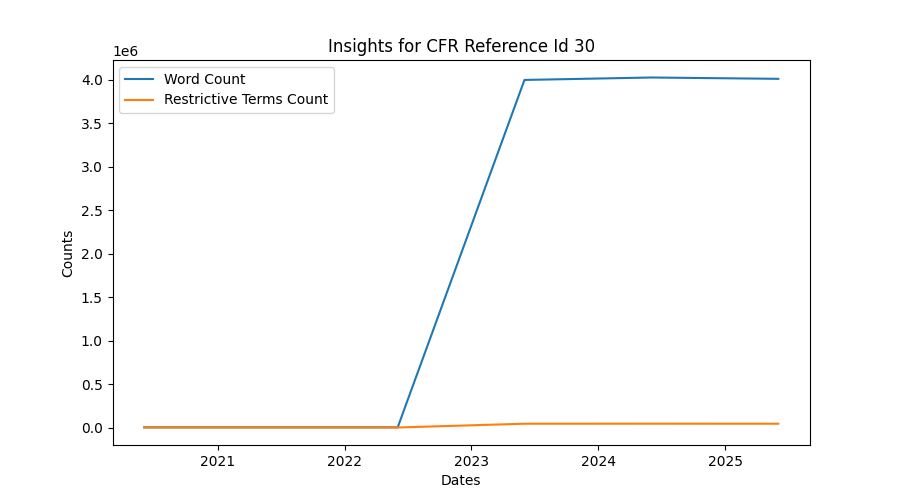

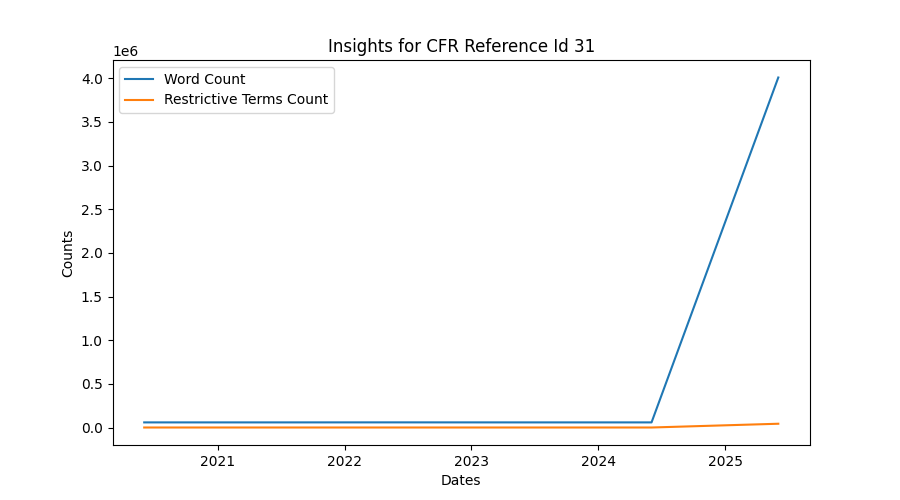

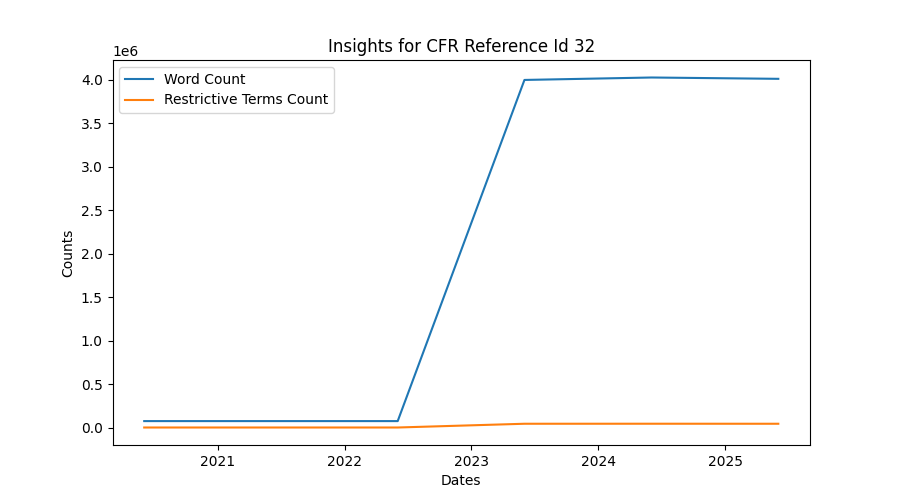

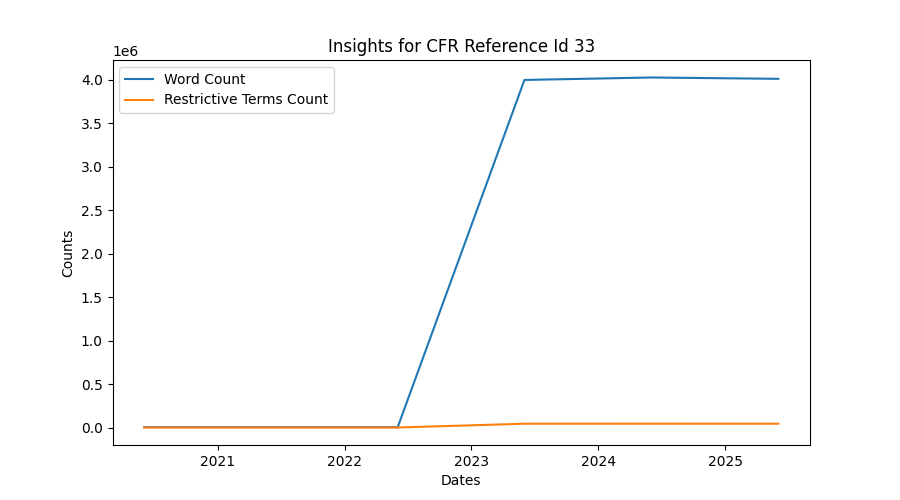

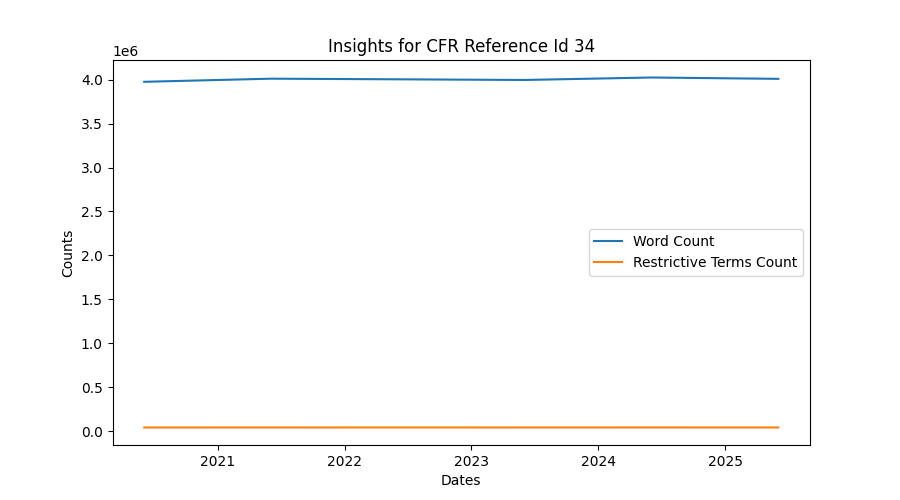

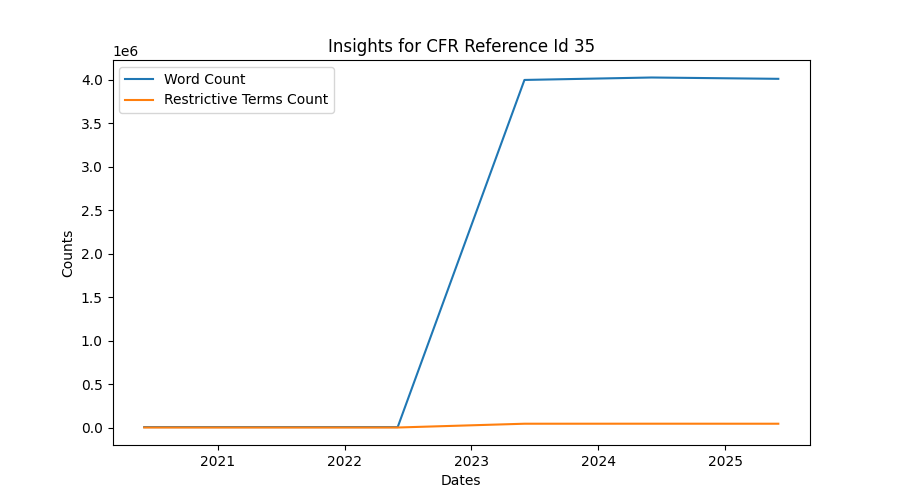

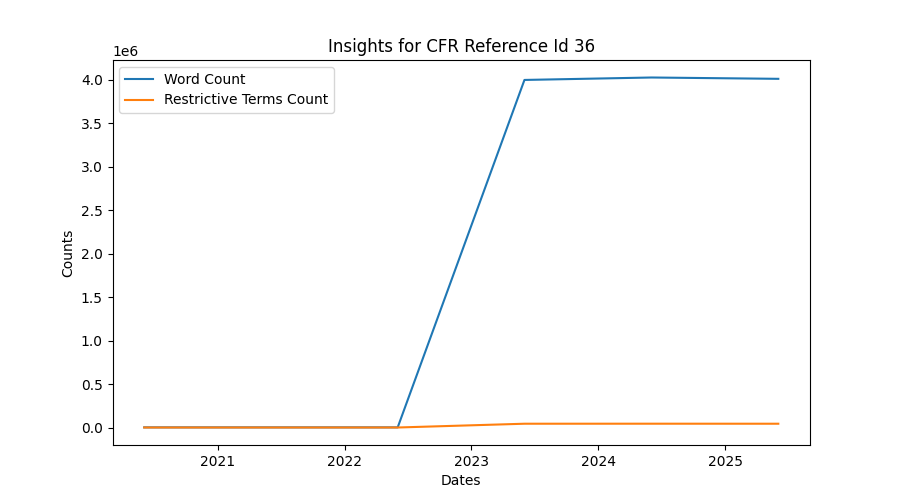

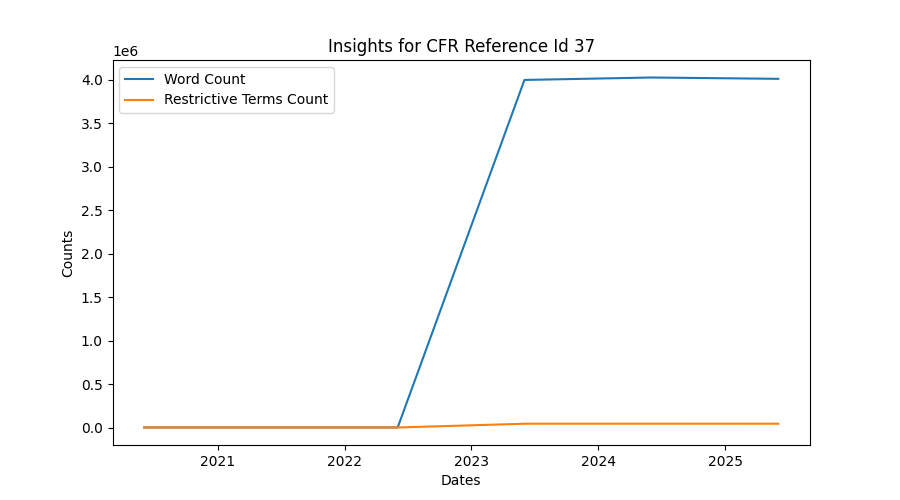

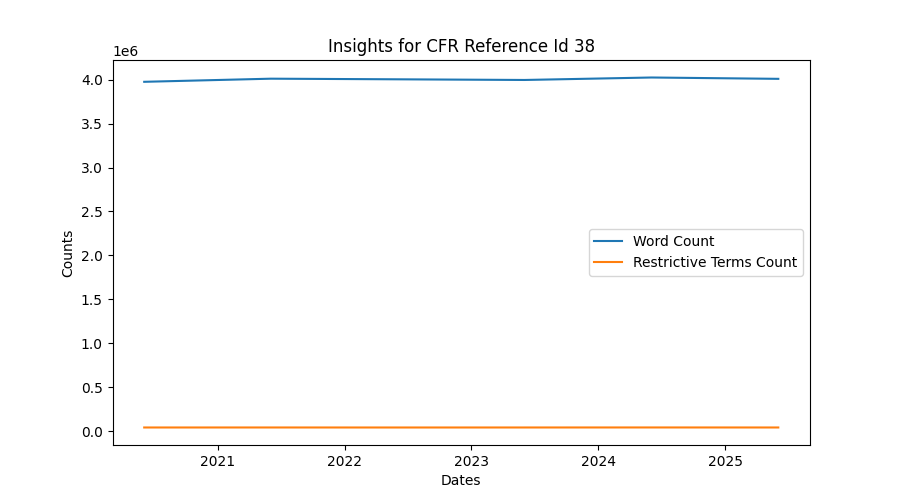

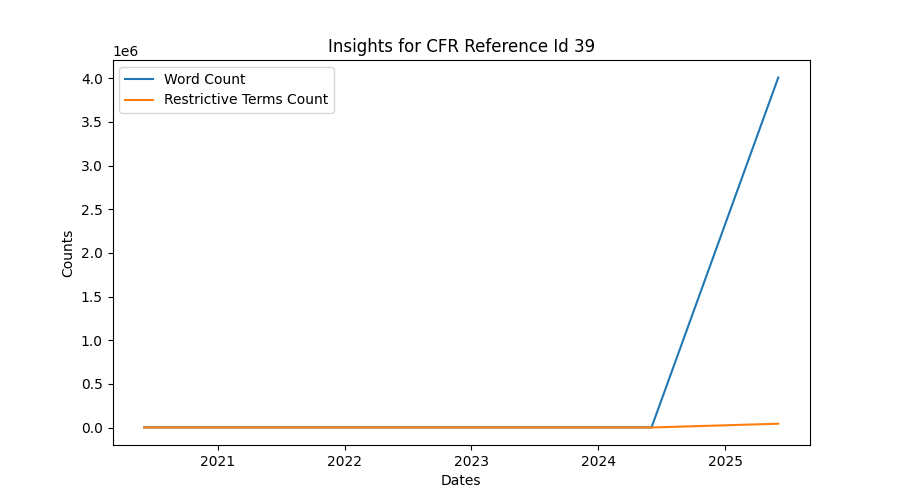

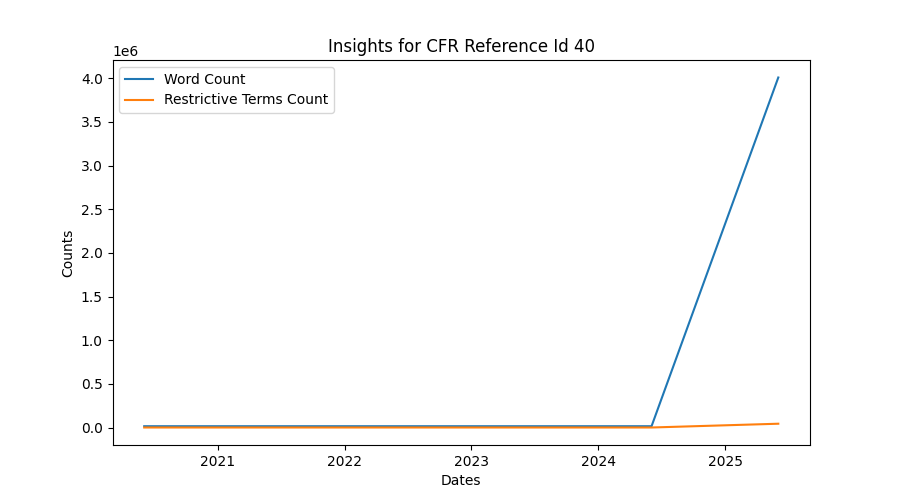

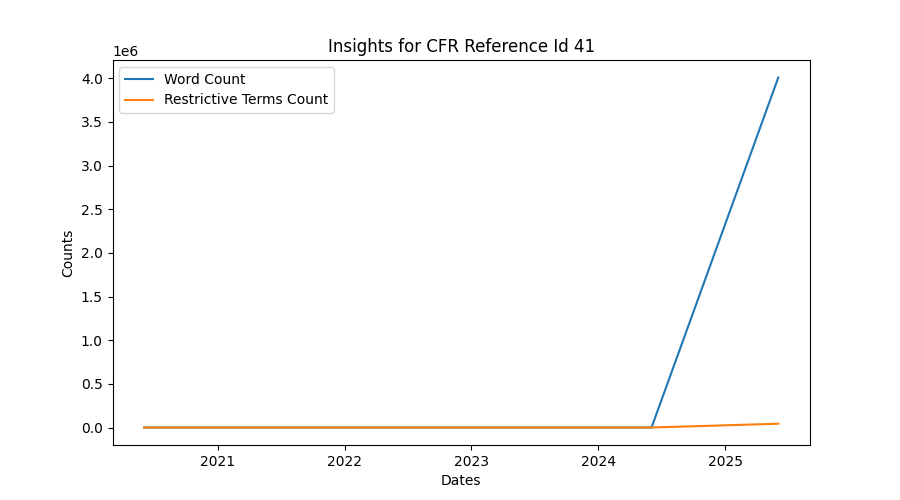

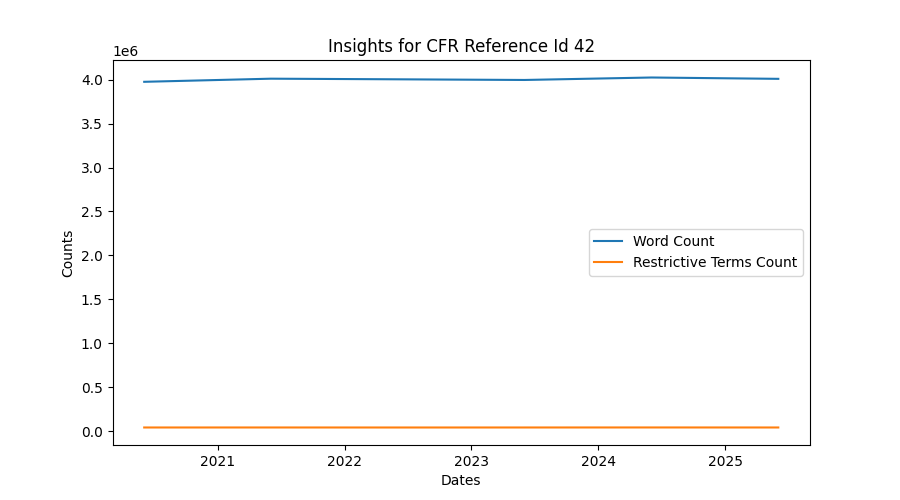

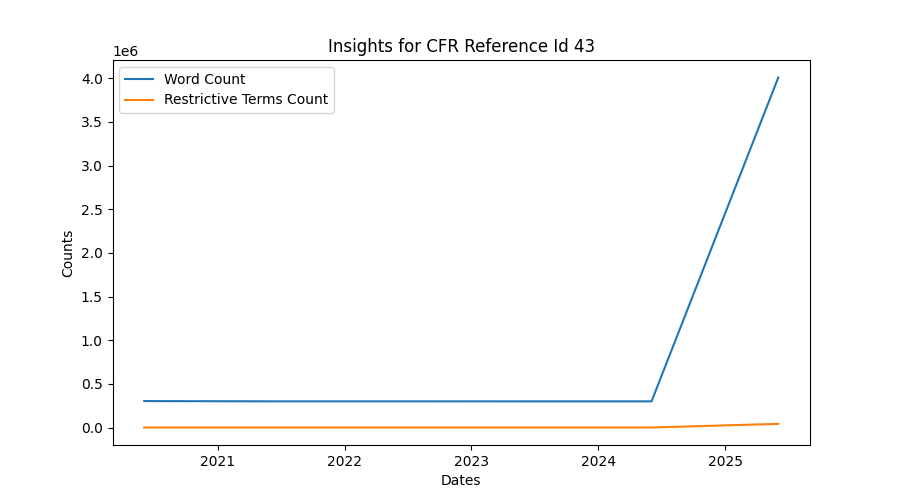

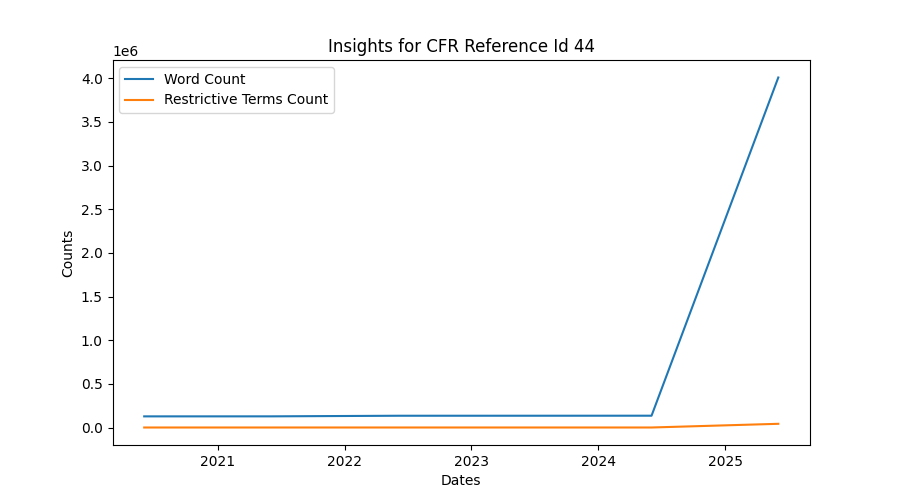

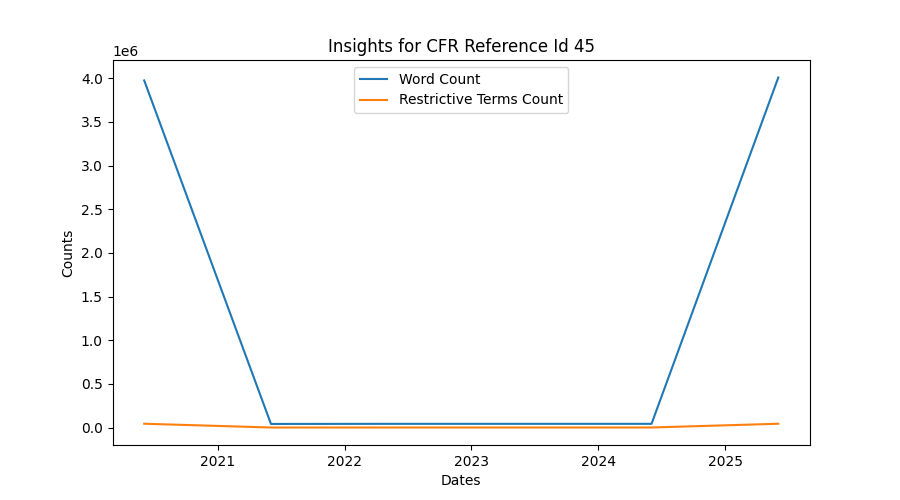

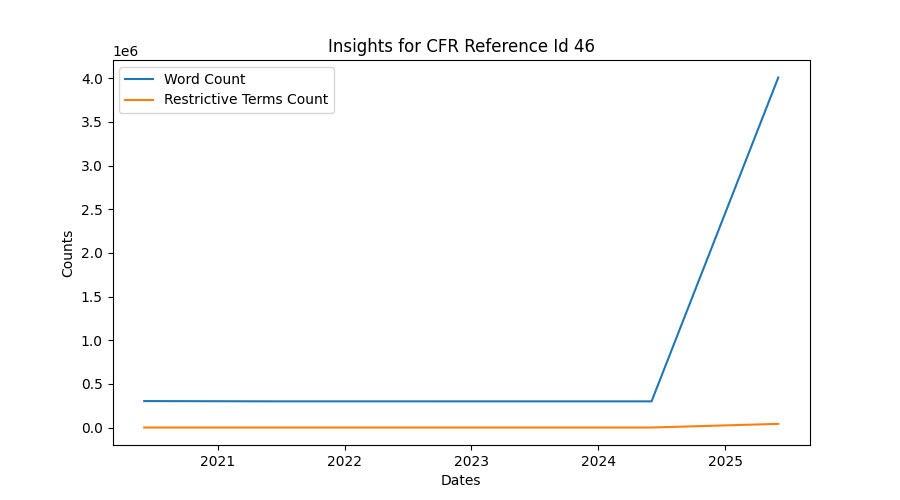

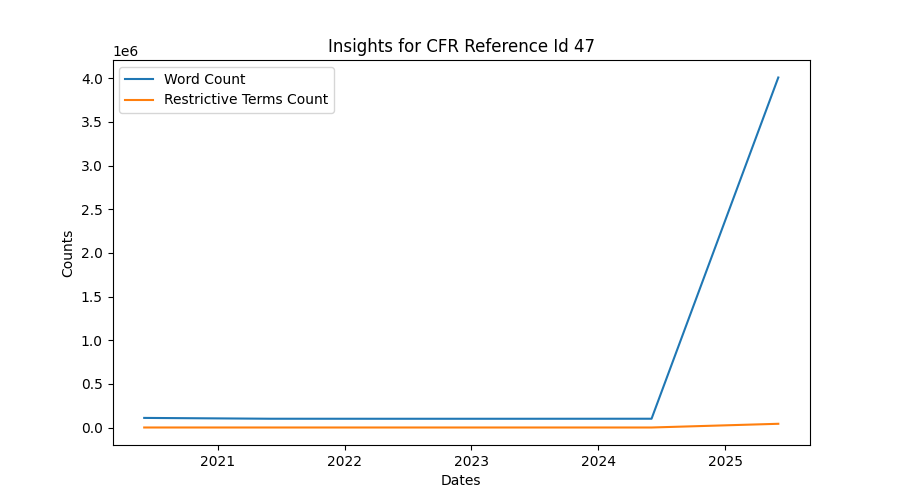

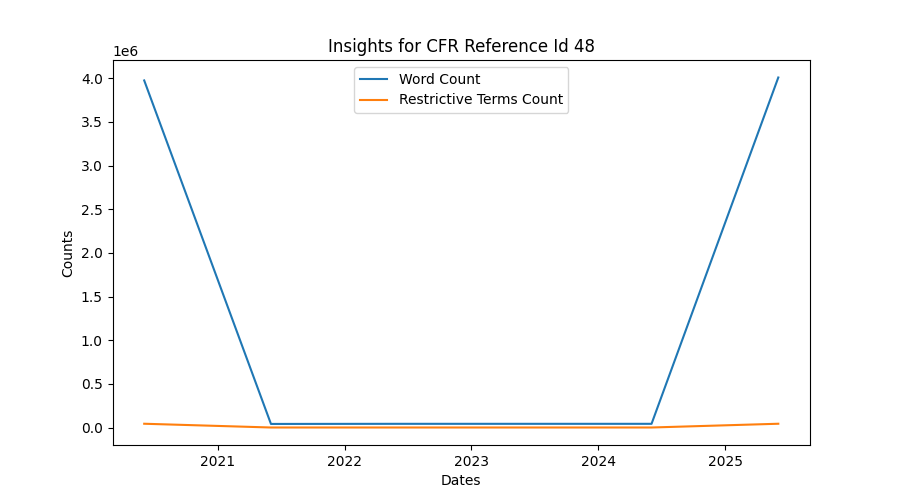

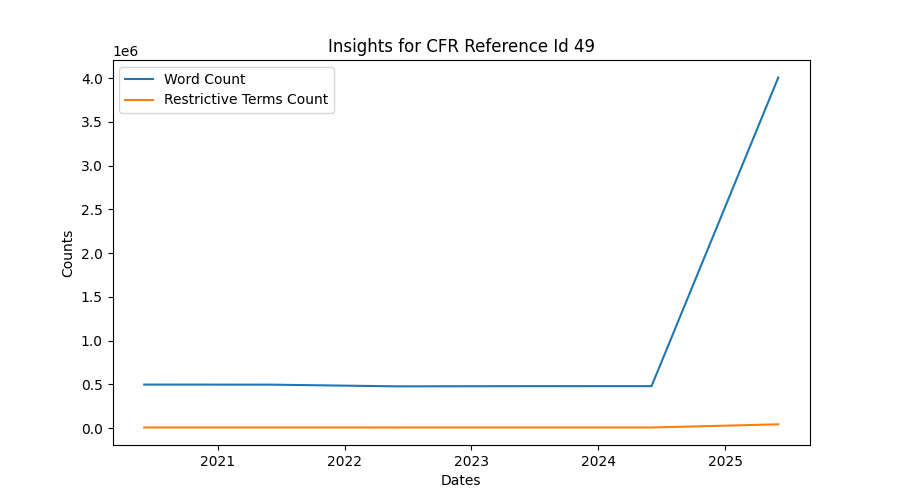

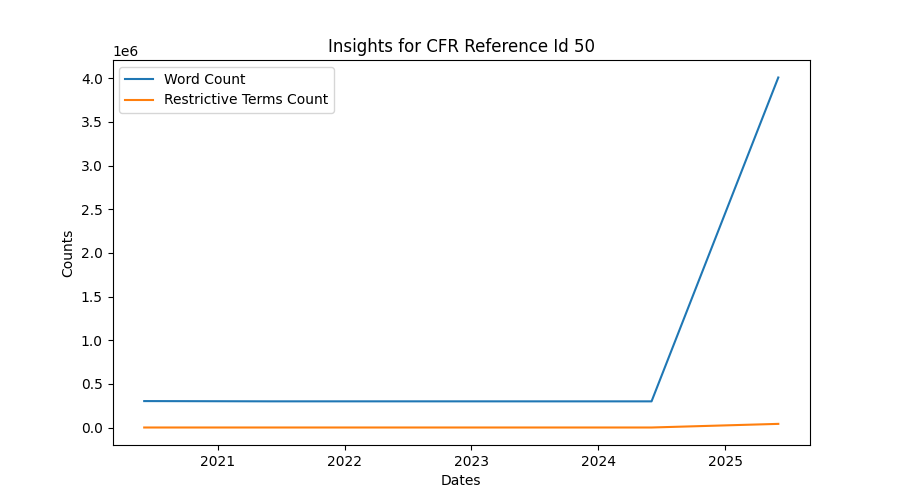

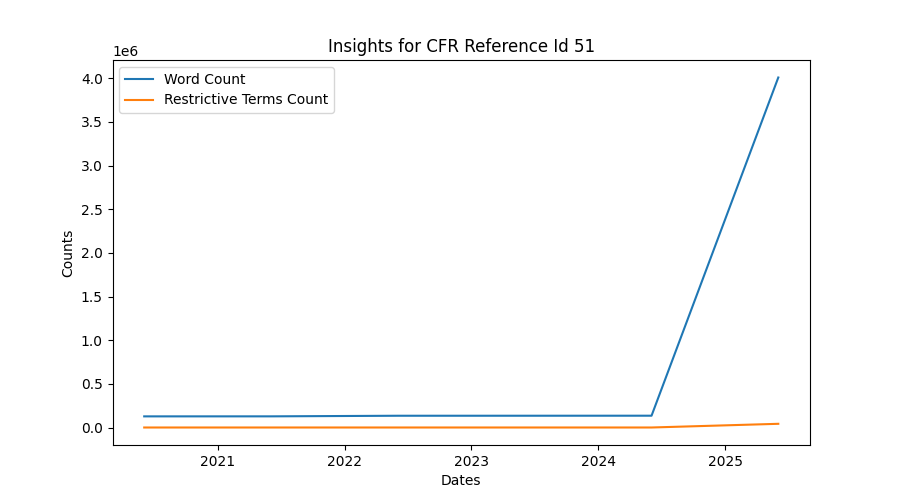

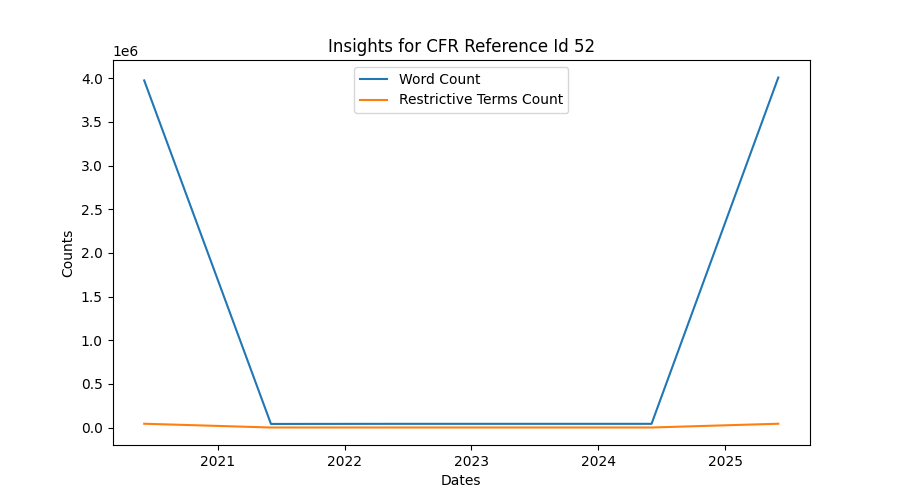

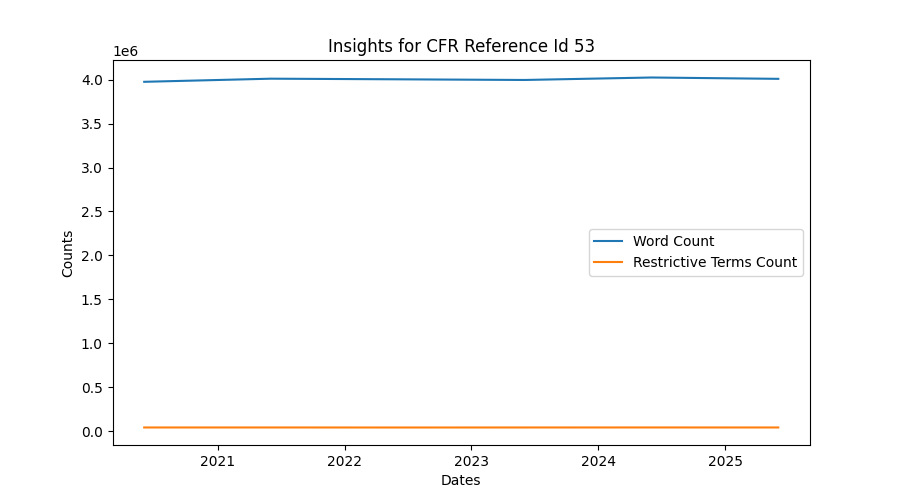

In [14]:
for key, value in insights_by_reference_id.items():
    value.sort(key=lambda d: d["date"])
    y_word_counts = [d.get("word_count") for d in value]
    y_restrictive_terms_counts = [d.get("restrictive_terms_count") for d in value]
    x_dates = pd.to_datetime([d.get("date") for d in value])
    plt.figure(figsize=(9, 5))
    plt.plot(x_dates, y_word_counts)
    plt.plot(x_dates, y_restrictive_terms_counts)
    plt.title("Insights for CFR Reference Id " + str(key))
    plt.xlabel("Dates")
    plt.ylabel("Counts")
    plt.legend(["Word Count", "Restrictive Terms Count"])
    plt.show()